## Benchmark Dataset 1

The first dataset to be employed as a benchmark for the implementation of the $L_2$-TWSVM and $L_1$-TWSVM models (with feature selection per hyperplane) was provided from the University of California, Irvine (UCI) Machine Learning Repository. This dataset consists of 13 clinical attributes collected from a cohort of up to 303 patients.

The original target variable encodes the presence and severity of coronary artery disease, assigning values from 0 to 4, where 0 denotes absence of disease and values 1 through 4 correspond to different severity of diagnosed heart disease. For the purposes of this study, the problem is reformulated as a binary classification task by aggregating all non-zero categories into a single positive class, thereby distinguishing between patients with heart disease and those without.

This dataset is typically used as a benchmark to evaluate the performance of $SVM$, $L_2$-TWSVM and $L_1$-TWSVM models, with particular emphasis on their performance handling clinical binary classification problems.


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
  
# Random seed
init_seed = 100453109

# Fetch the desired dataset from University of California, Irvine's Machine Learning Repository
heart_disease = fetch_ucirepo(id=45) 

# Store Benchmark dataset as pandas
X = heart_disease.data.features
Y = heart_disease.data.targets

# Remove NAs from the entire dataset
data = pd.concat([X, Y], axis = 1).dropna()
X = data.drop(columns = ['num'])
# Store feature names as numpy array (for representing feature importance)
features_names = np.array(X.columns)
Y = data[['num']]
Y = pd.DataFrame(np.where(Y == 0, 1, -1), columns = ['diagnosis'])

# Distribution of target classes (significant imbalance on target distribution)
print('Shape of features benchmark dataset 1 {}'.format(X.shape)) # Notice the original size of the dataset was 303 (just 6 patients observations were removed due to NAs values)
print('Distribution of target variable')
print(100 * Y.value_counts() / len(Y))
print('Unique classes', Y.nunique())

ConnectionError: Error connecting to server

## Benchmark Dataset 2

The second benchmark dataset was also provided by the UCI's Machine Learning Repository and comprises 569 observations of breast cancer clinical patients over 30 different features computed from digitalized images of a fine needle aspirate (FNA) of breast mass.

In [86]:
#Fetch the desired dataset as a dictionary
breast_cancer_dataset = fetch_ucirepo(id = 17)

# Store the desired data as pandas datasets
X = breast_cancer_dataset.data.features
Y = breast_cancer_dataset.data.targets
# Store feature names numpy array
features_names = np.array(X.columns)
# Encode the Y target dataset, 'B' (Benign) == positive class, +1, 'M' (Malign) == negative class, -1
Y = pd.DataFrame(np.where(Y == 'B', 1, -1), columns = ['diagnosis'])

# Distribution of target classes (significant imbalance on target distribution)
print('Shape of features benchmark dataset 1 {}'.format(X.shape)) # 6 patients had either NaN on ca or thal features
print('Distribution of target variable')
print(100 * Y.value_counts() / len(Y))
print('Unique classes', Y.nunique())

ConnectionError: Error connecting to server

In [ ]:
# Holdout as outer evaluation, estimation of future performance (stratification ensures similar target distribution on train- test split)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2, random_state= init_seed, stratify = Y)

# Convert the splits into numpy arrays to better handle them
X_train = X_train.to_numpy()
Y_train = Y_train['diagnosis'].to_numpy().ravel()
X_test = X_test.to_numpy()
Y_test = Y_test['diagnosis'].to_numpy().ravel()

# Group training set by classes forming the standard A, B matrices
A = X_train[Y_train == 1] # (class 1) No Heart disease/ Benign training observations
B = X_train[Y_train == -1] # (class -1) Heart Disease/ Malign training observations

## Soft margin TWSVM (Standard $L_2$-TWSVM)

The soft margin TWSVM is defines as,
$$
\begin{align*}
& \min_{w_1, b_1, \xi_2}\frac{1}{2}\|Aw_1+e_1b_1\|^2 + c_1e_2^T \xi_2 \\
& \text{s.t} \\

& \begin{cases} 
& -(Bw_1+e_2b_1)+\xi_2 \geq e_2 \\
& \xi_2 \geq 0
\end{cases} \\

& \text{and} \\
& \min_{w_2, b_2, \xi_1}\frac{1}{2}\|Bw_2+e_2b_2\|^2 + c_2e_1^T \xi_1 \\
& \text{s.t} \\

& \begin{cases} 
& Aw_2+e_1b_2 +\xi_1 \geq e_1 \\
& \xi_1 \geq 0
\end{cases}

\end{align*}
$$

where, $w_1, w_2 \in R^{N}$, $b_1, b_2 \in \R$ and $\xi_1 \in R^{m_1}$ $\xi_2 \in R^{m_2}$ are the variables to be optimized. Meanwhile, $e_1 = \vec{1} \in R^{m_1}$, $e_2 = \vec{1} \in R^{m_2}$ and the matrices containing the observations of each of the classes $A \in R^{m_1xN}$ (class 1 obs), $B \in R^{m_2xN}$ (class -1 obs) are given. Moreover, $c_1, c_2 \in \R$ are hyperparameters controlling the trade-off between margin violations penalization and least square fitting.

In [ ]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

# Gurobi supports QP
solver = pyo.SolverFactory('gurobi')

# Dimensions of class 1, class -1 datasets
A_nrows, A_ncols = A.shape
B_nrows, B_ncols = B.shape

# hyperparameters controlling penalization
c1 = 1.0
c2 = 2.2

In [ ]:
model_1 = pyo.ConcreteModel('Soft Margins TWSVM 1')

# Sets in TWSVM 1
model_1.N = pyo.RangeSet(0, A_ncols - 1) # number of features
model_1.I = pyo.RangeSet(0, A_nrows - 1) # number of class 1 observations
model_1.J = pyo.RangeSet(0, B_nrows - 1) # number of class -1 observations

# Variables for TWSVM 1
# Variables defining hyperplane for class 1
model_1.w1 = pyo.Var(model_1.N, domain = pyo.Reals)
model_1.b1 = pyo.Var(domain=pyo.Reals)

# Slack variables hyperplane class -1
model_1.xi2 = pyo.Var(model_1.J, domain = pyo.NonNegativeReals)

# TWSVM 1 objective
def h1_objective(model_1):
    ls_term = sum(
        (sum(A[i,n] * model_1.w1[n] for n in model_1.N) + model_1.b1)**2
        for i in model_1.I
        )
    penalt_term = c1 * sum(model_1.xi2[j] for j in model_1.J)
    
    return 0.5 * ls_term + penalt_term

model_1.obj1 = pyo.Objective(rule = h1_objective, sense = pyo.minimize)

# TWSVM 1 constraint
def h1_constraint(model_1, j):
    return -(sum(B[j,n] * model_1.w1[n] for n in model_1.N) + model_1.b1) + model_1.xi2[j] >= 1

model_1.constraint1 = pyo.Constraint(model_1.J, rule = h1_constraint)

# TWSVM 1 solution
solutions_h1 = solver.solve(model_1, tee = True)

Read LP format model from file C:\Users\danie\AppData\Local\Temp\tmpp1n42_31.pyomo.lp
Reading time = 0.05 seconds
x1: 170 rows, 201 columns, 5440 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 170 rows, 201 columns and 5440 nonzeros (Min)
Model fingerprint: 0x1d0dfadb
Model has 170 linear objective coefficients
Model has 496 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e-03, 4e+03]
  Objective range  [1e+00, 1e+00]
  QObjective range [6e-03, 2e+08]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.

Presolve time: 0.02s
Presolved: 170 rows, 201 columns, 5440 nonzeros
Presolved model has 496 quadratic obj

In [ ]:
# Retrieve w1*
twsvm_opt_w1 = np.array([pyo.value(model_1.w1[n]) for n in model_1.N])
print(f'w1* ={twsvm_opt_w1}')
# Retrieve b1*
twsvm_opt_b1 = pyo.value(model_1.b1)
print(f'b1* ={twsvm_opt_b1}')
# retrieve slack variable xi2 associated to H1
opt_xi2 = np.array([pyo.value(model_1.xi2[j]) for j in model_1.J])

w1 =[-7.89728055e-02 -2.36442969e-02  2.75045118e-02  8.85208024e-04
 -5.65747921e+00  6.00890757e+00 -8.57411952e+00  3.34530807e+00
  6.57052702e-01 -5.87039353e+00  9.64090894e-01  8.64048937e-02
  6.70643056e-02 -2.32138316e-02 -3.92559404e+01  8.16771502e+00
  7.74626367e+00 -2.37635857e+01  3.26948440e+00  3.02563417e+00
  6.94016754e-02  4.74895643e-04  1.44857680e-02 -3.84942884e-03
  4.44623978e+00 -2.85387469e+00  6.75369994e-01 -6.11971768e-01
 -2.12550983e+00  2.37601134e+00]
b1 =-0.357353452874527


In [ ]:
model_2 = pyo.ConcreteModel('Soft Margin TWSVM 2')

# Sets for TWSVM 2
model_2.N = pyo.RangeSet(0, A_ncols - 1) # number of features
model_2.I = pyo.RangeSet(0, A_nrows - 1) # number of class 1 observations
model_2.J = pyo.RangeSet(0, B_nrows - 1) # number of class -1 observations

# Variables defining hyperplane for class 2
model_2.w2 = pyo.Var(model_2.N, domain = pyo.Reals)
model_2.b2 = pyo.Var(domain=pyo.Reals)

# Slack variables hyperplane class 1
model_2.xi1 = pyo.Var(model_2.I, domain = pyo.NonNegativeReals)

# TWSVM 2 objective
def h2_objective(model_2):
    ls_term = sum(
            (sum(B[j,n] * model_2.w2[n] for n in model_2.N) + model_2.b2)**2
        for j in model_2.J
    )
    penalt_term = c2 * sum(model_2.xi1[i] for i in model_2.I)

    return 0.5 * ls_term + penalt_term

model_2.obj2 = pyo.Objective(rule = h2_objective, sense = pyo.minimize)

# TWSVM 2 constraint
def h2_constraint(model_2, i):
    return sum(A[i,n] * model_2.w2[n] for n in model_2.N) + model_2.b2 + model_2.xi1[i] >= 1

model_2.constraint2 = pyo.Constraint(model_2.I, rule = h2_constraint)

# solutions TWSVM 2
solutions_h2 = solver.solve(model_2, tee = True)

Read LP format model from file C:\Users\danie\AppData\Local\Temp\tmpcv10n25_.pyomo.lp
Reading time = 0.05 seconds
x1: 285 rows, 316 columns, 9054 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 285 rows, 316 columns and 9054 nonzeros (Min)
Model fingerprint: 0xd36e23f3
Model has 285 linear objective coefficients
Model has 496 quadratic objective terms
Coefficient statistics:
  Matrix range     [7e-04, 1e+03]
  Objective range  [2e+00, 2e+00]
  QObjective range [4e-03, 5e+08]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.

Presolve time: 0.02s
Presolved: 285 rows, 316 columns, 9054 nonzeros
Presolved model has 496 quadratic obj

In [ ]:
# w2*
twsvm_opt_w2 = np.array([pyo.value(model_2.w2[n]) for n in model_2.N])
print(f'w2* ={twsvm_opt_w2}')
# b2*
twsvm_opt_b2 = pyo.value(model_2.b2)
print(f'b2* ={twsvm_opt_b2}')
# Slack variable xi1 associated with H2
opt_xi1 = np.array([pyo.value(model_2.xi1[j]) for j in model_2.J])

w2 =[ 2.84166685e-01 -1.43656439e-02 -5.23436696e-02  8.13630833e-04
  3.59744968e+00  4.33197033e+00  7.74529332e-01 -5.86992934e+00
 -1.75544091e+00  8.84659815e+00 -2.57570611e-01 -3.58518653e-02
 -2.09542555e-03 -1.75796796e-03 -3.23963299e+01  8.67444406e-01
 -6.07115324e-02 -1.20863097e+01  7.24225692e+00  2.30590283e+01
 -3.93153406e-01 -9.47343888e-03  1.43396354e-02  1.98128158e-03
 -5.46214225e+00  4.35534728e-01 -7.36706139e-01 -6.06313073e-01
 -1.70946596e+00 -6.89534972e+00]
b2 =6.392891709443475


## TWSVM with Embedded Feature Selection ($L_1$-TWSVM)

L1-TWSVM introduces $L_1$ norm of the regularization terms of each hyperplane namely, $Aw_1 + e_1b_1$ and $Bw_2 + e_2b_2$, as well as the $L_1$-norm of the weights vectors $w_i$, $i=1, 2$ as in Bai, L. Wang, Z. Shao Y.H & Deng, N. Y (2014)

$$
\begin{align*}
&\min_{w_1, b_1, \xi_2}\;\; \|w_1\|_1 + c_1\|Aw_1+e_1b_1\|_1 + c_3e_2^T\xi_2 \\
&\text{s.t} \\
&\begin{cases}
& -(Bw_1+e_2b_1) \geq e_2 - \xi_2 \\
& \xi_2 \geq 0
\end{cases} \\
&\text{and} \\[2ex]
&\min_{w_2, b_2, \xi_1}\;\;\|w_2\|_1 + c_2\|Bw_2+e_2b_2\|_1 + c_4e_1^T\xi_1 \\
&\text{s.t} \\
&\begin{cases}
& (Aw_2+e_1b_2) \geq e_1 - \xi_1 \\
& \xi_1 \geq 0
\end{cases}
\end{align*}
$$

The earlier representation of the $L_1$-TWSVM compose a Nondifferentiable Programming Problem due to the presence on the objective function of non linear term as, $\|w_1\|_1 = \sum_{n=1}^N|w_n^{(1)}|$ and $\|Aw_1+e_1b_1\|_1 = \sum_{i=1}^{m_1}|\sum_{n=1}^Na_{i,n}w_n^{(1)} + b_1|$ in the definition of the first TWSVM hyperplane.

This problem can be transformed into a Differentiable Linear Programming Problem (DLPP) to be solved by the version of the Simplex algorithm implemented by the Gurobi optimizer just by introducing the following auxiliar variables, $w_i = p_i - q_i$ as well as, $Aw_1 + e_ib_1 = s_1 - t_i$ and $Bw_2 + e_2b_2 = s_2 - t_2$.

The auxiliary variables introduce a positive-negative decomposition of the weight vectors and residual terms, where each variable is expressed as the difference of two nonnegative variables. This allows their absolute values to be represented as the sum of these components, thereby enabling a linear formulation of the $L_1$-TWSVM.

\begin{align*}
& \min_{p_1,q_1,s_1,t_1,b_1,\xi_2} e_1^T(p_1 + q_1) + c_1e_1^T(s_1 + t_1) + c_3e_1^T\xi_1 \\
& \text{s.t} \\
& \begin{cases}
& A(p_1 - q_1) + e_1b_1 = s_1 - t_1 \\
& -B(p_1 - q_1) + e_2b_1 \geq e_2 - \xi_2 \\
& p_1, q_1, s_1, t_1, \xi_2 \geq 0
\end{cases} \\
& \text{and} \\
& \min_{p_2,q_2,s_2,t_2,b_2,\xi_1} e_2^T(p_2 + q_2) + c_2e_2^T(s_2 + t_2) + c_4e_2^T\xi_1 \\
& \text{s.t} \\
& \begin{cases}
& B(p_2 - q_2) + e_2b_2 = s_2 - t_2 \\
& A(p_2 - q_2) + e_1b_2 \geq e_1 - \xi_1 \\
& p_2,q_2,s_2,t_2,\xi_1
\end{cases}
\end{align*}

Noticing, $s_1 = A(p_1 - q_1) + e_1b_1 + t_1$ and $s_2 = B(p_2 - q_2) + e_2b_2 + t_2$ the final DLPPs to be solved by Gurobi's Simplex algorithm implementation are defined,

$$
\begin{align*}
& \min_{p_1,q_1,t_1,b_1,\xi_2} e_1^T(p_1+q_1) + c_1e_1^T(A(p_1 -q_1) + 2t_1) + c_1m_1b_1 + c_3e_1^T\xi_2 \\
& \text{s.t} \\
& \begin{cases}
& A(p_1 - q_1) + e_1b_1 + t_1 \geq 0 \\
& -B(p_1-q_1) + e_2b_1 \geq e_2 - \xi_2 \\
& p_1, q_1, t_1, \xi_2 \geq 0 
\end{cases} \\
& \text{and} \\
& \min_{p_2,q_2,t_2,b_2,\xi_1} e^T(p_2 + q_2) + c_2e^T(B(p_2 - q_2) + 2t_2) + c_2m_2b_2 + c_4e^T\xi_1 \\
& \text{s.t} \\
& \begin{cases}
& B(p_2-q_2) + e_2b_2 + t_2 \geq 0 \\
& A(p_2-q_2) + e_1b_2 \geq e_1 - \xi_1 \\
& p_2,q_2,t_2,\xi_1 \geq 0
\end{cases}
\end{align*}
$$

where $m_1 = e_1^Te_1$ and $m_2 = e_2^Te_2$ denote the total training observations of each class respectively.

In [ ]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
# Gurobi support Quadratic Programming Problems (QPPs)
solver = SolverFactory('gurobi')

# dimension of the datasets
A_nrows, A_ncols = A.shape
B_nrows, B_ncols = B.shape

# LS fitting weight terms
c1 = 0.5
c2 = 0.5
# regularization term 
c3 = 1.0
c4 = 1.0

In [ ]:
model_1 = pyo.ConcreteModel('Individual FS TWSVM 1')

# Sets
model_1.N = pyo.RangeSet(0, A_ncols - 1) # number of dimensions
model_1.I = pyo.RangeSet(0, A_nrows -1) # m1, number of class 1 obs
model_1.J = pyo.RangeSet(0, B_nrows -1) # m2, number of class -1 obs

# Variables
model_1.b1 = pyo.Var(domain = pyo.Reals)
model_1.xi2 = pyo.Var(model_1.J, domain = pyo.NonNegativeReals)
# Aux vars for computing the abs value of w_1 as |w_1| = p1 + q1
model_1.p1 = pyo.Var(model_1.N, domain = pyo.NonNegativeReals) # Aux var p1 (w_1 = p1 - q1)
model_1.q1 = pyo.Var(model_1.N, domain = pyo.NonNegativeReals) # Aux var q1 (w_1 = p1 - q1)
# Aux vars for computing the abs value of Aw_1 + e_1b_1 as |Aw_1 + e_1b_1| = s1 + t1
model_1.t1 = pyo.Var(model_1.I, domain = pyo.NonNegativeReals) # Aux var t1 (Aw_1 + e_1b_1 = s_1 - t_1)

# TWSVM 1 Objective function
def h1_objective(model_1):
    fs_term = sum((model_1.p1[n] + model_1.q1[n]) for n in model_1.N)
    ls_term1 = sum(
        sum(A[i,n] * (model_1.p1[n] - model_1.q1[n]) for n in model_1.N) + 2 * model_1.t1[i]
        for i in model_1.I
    )
    ls_term2 = len(model_1.I) * model_1.b1
    penalty_term = sum(model_1.xi2[j] for j in model_1.J)
    return fs_term + c1 * ls_term1 + c1 * ls_term2 + c3 * penalty_term

model_1.obj = pyo.Objective(rule = h1_objective, sense = pyo.minimize)

# TWSVM 1 s1 aux variable definition constraint
def h1Constraint_1(model_1, i):
    return sum(A[i,n] * (model_1.p1[n] - model_1.q1[n]) for n in model_1.N) + model_1.t1[i] + model_1.b1 >= 0

model_1.constraint1 = pyo.Constraint(model_1.I, rule = h1Constraint_1)

# TWSVM 1 h2 hyperplane separation constraint with margin violations
def h1Constraint_2(model_1, j):
    return -(sum(B[j,n] * (model_1.p1[n] - model_1.q1[n]) for n in model_1.N) + model_1.b1) >= 1 - model_1.xi2[j]

model_1.constraint2 = pyo.Constraint(model_1.J, rule = h1Constraint_2)

solution_h1 = solver.solve(model_1, tee = True)

Read LP format model from file C:\Users\danie\AppData\Local\Temp\tmp2popwnq_.pyomo.lp
Reading time = 0.08 seconds
x1: 455 rows, 516 columns, 28078 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 455 rows, 516 columns and 28078 nonzeros (Min)
Model fingerprint: 0x1d5bc375
Model has 516 linear objective coefficients
Coefficient statistics:
  Matrix range     [7e-04, 4e+03]
  Objective range  [2e-02, 8e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]

Presolve removed 0 rows and 1 columns
Presolve time: 0.02s
Presolved: 455 rows, 515 columns, 27623 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
     453    3.6546894e+01   0.000000e+00   0.0000

In [ ]:
# Retrieve w1* = p1 - q1
fstwsvm_opt_w1 = np.array([pyo.value(model_1.p1[n]) - pyo.value(model_1.q1[n]) for n in model_1.N])
print(f'w1* ={fstwsvm_opt_w1}')
# Retrieve b1*
fstwsvm_opt_b1 = pyo.value(model_1.b1)
print(f'b1* ={fstwsvm_opt_b1}')
# Retrieve slack variables xi2 for H1
opt_xi2 = np.array([pyo.value(model_1.xi2[j]) for j in model_1.J])

w1 =[ 3.18005992e-01 -7.70201947e-03 -5.50336412e-02  2.47273317e-03
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  1.06402484e-01 -1.40840994e-02  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  3.94295862e-01 -7.90088184e-04 -8.66809376e-03 -6.03884953e-03
  0.00000000e+00 -3.74343806e-01 -8.14212995e-02 -1.16819643e-02
 -1.08306356e+00  0.00000000e+00]
b1 =-1.325031601329238


In [ ]:
model_2 = pyo.ConcreteModel('Individual FS TWSVM 2')

# Sets
model_2.N = pyo.RangeSet(0, A_ncols -1) #dimensionality
model_2.I = pyo.RangeSet(0, A_nrows -1) # m1, number of class 1 observations
model_2.J = pyo.RangeSet(0, B_nrows -1) # m2, number of class -1 observations

# Variables
model_2.b2 = pyo.Var(domain = pyo.Reals)
model_2.xi1 = pyo.Var(model_2.I, domain = pyo.NonNegativeReals)
# Aux vars for computing the abs value of w_2 as |w_2| = p2 + q2
model_2.p2 = pyo.Var(model_2.N, domain = pyo.NonNegativeReals) # Aux var p1 (w_2 = p2 - q2)
model_2.q2 = pyo.Var(model_2.N, domain = pyo.NonNegativeReals) # Aux var q1 (w_2 = p2 - q2)
# Aux vars for computing the abs value of Bw_2 + e_2b_2 as |Bw_2 + e_2b_2| = s2 + t2
model_2.t2 = pyo.Var(model_2.J, domain = pyo.NonNegativeReals) # Aux var t2 (Bw_2 + e_2b_2 = s_2 - t_2)

# TWSVM 2 Objective function
def h2_objective(model_2):
    fs_term = sum((model_2.p2[n] + model_2.q2[n]) for n in model_2.N)
    ls_term1 = sum(
        sum(B[j,n] * (model_2.p2[n] - model_2.q2[n]) for n in model_2.N) + 2 * model_2.t2[j]
        for j in model_2.J
    )
    ls_term2 = len(model_2.J) * model_2.b2
    penalty_term = sum(model_2.xi1[i] for i in model_2.I)
    return fs_term + c2 * ls_term1 + c2 * ls_term2 + c4 * penalty_term

model_2.obj = pyo.Objective(rule = h2_objective, sense = pyo.minimize)

# TWSVM 1 s1 aux variable definition constraint
def h2Constraint_1(model_2, j):
    return sum(B[j,n] * (model_2.p2[n] - model_2.q2[n]) for n in model_2.N) + model_2.t2[j] + model_2.b2 >= 0

model_2.constraint1 = pyo.Constraint(model_2.J, rule = h2Constraint_1)

# TWSVM 1 h2 hyperplane separation constraint with margin violations
def h2Constraint_2(model_2, i):
    return (sum(A[i,n] * (model_2.p2[n] - model_2.q2[n]) for n in model_2.N) + model_2.b2) >= 1 - model_2.xi1[i]

model_2.constraint2 = pyo.Constraint(model_2.I, rule = h2Constraint_2)

solution_h2 = solver.solve(model_2, tee = True)

Read LP format model from file C:\Users\danie\AppData\Local\Temp\tmpziyygieg.pyomo.lp
Reading time = 0.07 seconds
x1: 455 rows, 516 columns, 28078 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 455 rows, 516 columns and 28078 nonzeros (Min)
Model fingerprint: 0x5a685b93
Model has 516 linear objective coefficients
Coefficient statistics:
  Matrix range     [7e-04, 4e+03]
  Objective range  [3e-01, 1e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]

Presolve removed 0 rows and 2 columns
Presolve time: 0.02s
Presolved: 455 rows, 514 columns, 27168 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
     283    3.4215107e+01   0.000000e+00   0.0000

In [ ]:
# w2 = p2 - q2
fstwsvm_opt_w2 = np.array([pyo.value(model_2.p2[n]) - pyo.value(model_2.q2[n]) for n in model_2.N])
print(f'w2* ={fstwsvm_opt_w2}')
# b2*
fstwsvm_opt_b2 = pyo.value(model_2.b2)
print(f'b2* ={fstwsvm_opt_b2}')
opt_xi1 = np.array([pyo.value(model_2.xi1[i]) for i in model_2.I])

fstwsvm_params = [fstwsvm_opt_w1, fstwsvm_opt_b1, fstwsvm_opt_w2, fstwsvm_opt_b2]

w2* =[ 0.00000000e+00  1.97393235e-02  4.38351793e-03 -1.14633714e-04
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  2.00033854e-02 -4.08604728e-03  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -4.78354533e-01 -3.85074868e-02  5.23372249e-03  2.98393562e-03
  0.00000000e+00  0.00000000e+00 -5.25586316e-01 -4.31776925e-01
 -6.25444361e-01  0.00000000e+00]
b2* =6.368924650172948


**Post Hoc Feature Selection**

$L_1$-TWSVM directly compose an individual feature selection method per hyperplane by imposing sparsity on the weight vectors corresponding to each hyperplane such that the less relevant features see its weights be collapsed to zero. Each hyperplane selects relevant features by discarding those which weights are zero. Namely, $n_1$ would represent the set of significant features selected by solving the first $L_1$-TWSVM hyperplane and similarly $n_2$ for the second $L_1$-TWSVM hyperplane. 

In [ ]:
# set of features selected by L1-TWSVM
n1 = set(np.where(fstwsvm_opt_w1 != 0)[0])
n2 = set(np.where(fstwsvm_opt_w2 != 0)[0])

print(f"|n1| = {len(n1)}, |n2| = {len(n2)}, |n1 U n2| = {len(n1|n2)}")

# Define maximum total number of features to be selected
n_star = X.shape[1] - 3

# Prune selected features keeping those contributing with highest weights on both hyperplanes
if len(n1 | n2) > n_star:
    union_weights = {}
    for j in n1 | n2:
        union_weights[j] = np.abs(fstwsvm_opt_w1[j]) + np.abs(fstwsvm_opt_w2[j])

    fs = sorted(union_weights, key = union_weights.get, reverse = True)[:n_star]

    # Set artificially to zero the weights of those features that contribute less to both hyperplanes
    # in order to keep just the very first n* relevant features
    fstwsvm_opt_w1 = np.where(np.isin(range(len(fstwsvm_opt_w1)), fs), fstwsvm_opt_w1, 0)
    fstwsvm_opt_w2 = np.where(np.isin(range(len(fstwsvm_opt_w2)), fs), fstwsvm_opt_w2, 0)

|n1| = 14, |n2| = 12, |n1 U n2| = 14


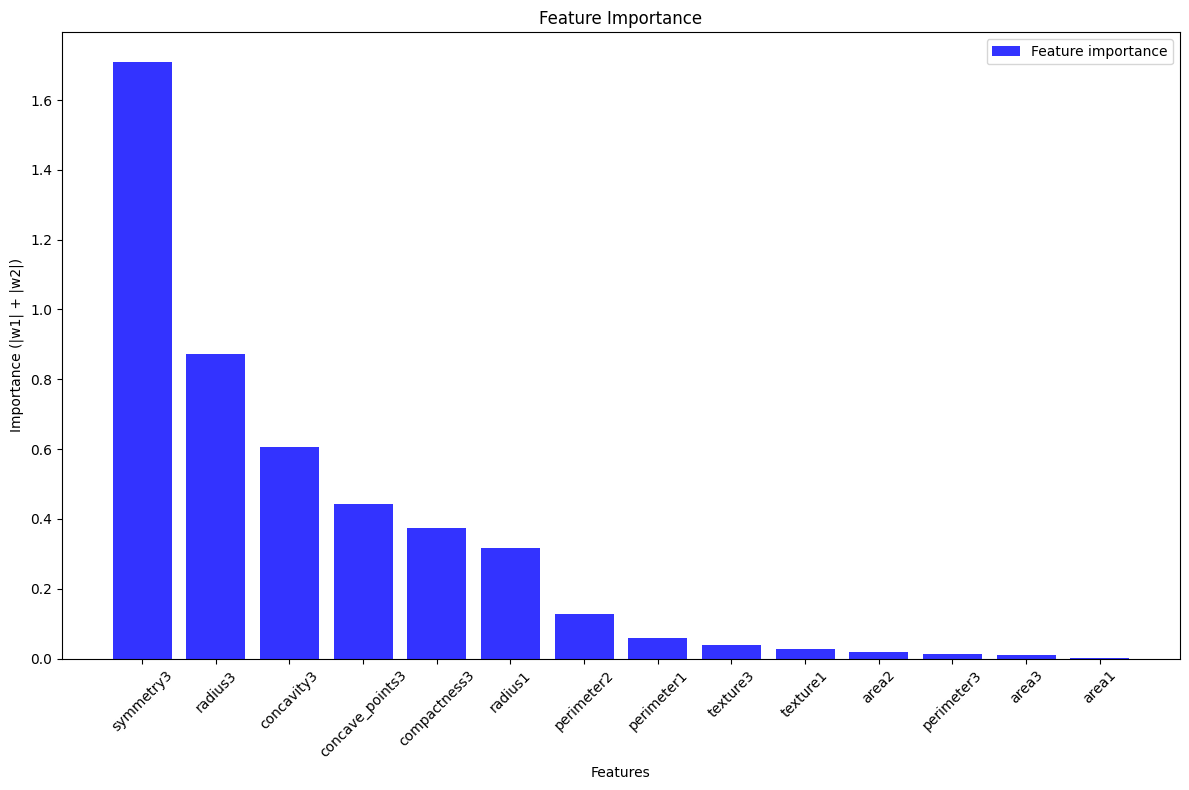

In [ ]:
importance = np.abs(fstwsvm_opt_w1) + np.abs(fstwsvm_opt_w2)

nonzero = np.where(importance!=0)[0]
idx = nonzero[np.argsort(importance[nonzero])[::-1]]

plt.figure(figsize=(12,8))
plt.bar(features_names[idx], importance[idx], color = 'blue', label = 'Feature importance', alpha = 0.8)
plt.xticks(rotation = 45)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance (|w1| + |w2|)")
plt.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

## Probability model for FTWSVM (TWSVM with Feature Selection)

Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012) propose a continuous scoring function to approximate the posterior probability of a sample $\tilde{x}$ belonging to a class. This score is constructed based on the geometric position of the sample $\tilde{x}$ relative to two auxiliary hyperplanes,
$$
\begin{cases}
\frac{w_1^T\tilde{x} + b_1}{\|w_1\|} - \frac{w_2^T\tilde{x} + b_2}{\|w_2\|} = 0 \\
\frac{w_1^T\tilde{x} + b_1}{\|w_1\|} + \frac{w_2^T\tilde{x} + b_2}{\|w_2\|} = 0
\end{cases}
$$

Defined the distances from the sample to those auxiliarly hyperplanes, $D_+(x) = \frac{|d_1(x) + d_2(x)|}{\|\frac{w_1}{\|w_1\|} + \frac{w_2}{\|w_2\|}\|}$ and $D_-(x) = \frac{|d_1(x) - d_2(x)|}{\|\frac{w_1}{\|w_1\|} - \frac{w_2}{\|w_2\|}\|}$, thus it can be identified the maximum and minimum distance from the sample to either auxiliarly hyperplane, $d(x)$ and $D(x)$ such that the relevant quantities $d(x)$ and $\frac{d(x)}{D(x)}$ can be defined.

It is observed that the higher either $d(x)$ or $\frac{d(x)}{D(x)}$ are the more likely a sample belongs to the positive class. Therefore the score function is defined as,

$$
f(x) = \begin{cases} d(x)(\frac{d(x)}{D(x)})^{\alpha} &\frac{|w_1^T\tilde{x} + b_1|}{\|w_1\|} < \frac{|w_2^T\tilde{x} + b_2|}{\|w_2\|}  \\
0 & \frac{|w_1^T\tilde{x} + b_1|}{\|w_1\|} = \frac{|w_2^T\tilde{x} + b_2|}{\|w_2\|} \\
-d(x)(\frac{d(x)}{D(x)})^{\alpha} & \frac{|w_1^T\tilde{x} + b_1|}{\|w_1\|} > \frac{|w_2^T\tilde{x} + b_2|}{\|w_2\|}
\end{cases}
$$

In [ ]:
def score_function(X, opt_params, alpha = 1):

    w1, b1, w2, b2 = opt_params
    # numeric stabilization
    eps = 1e-12

    # Weight vectors norms
    norm_w1 = max(np.linalg.norm(w1), eps)
    norm_w2 = max(np.linalg.norm(w2), eps)

    # euclidean distances to the separation hyperplanes derived from TWSVM
    d1 = (X @ w1 + b1) / norm_w1
    d2 = (X @ w2+ b2) / norm_w2

    # Normalized weight vectors
    w1_hat = w1 / norm_w1
    w2_hat = w2 / norm_w2

    # euclidean distances to the auxiliarly hyperplanes defined
    # the resulting D_plus, D_minus vectors have shape (n, ) measuring 
    # the euclidean dist to the each aux hyperplane for all n observations
    D_plus = np.abs(d1 + d2) / max(np.linalg.norm(w1_hat + w2_hat), eps)
    D_minus = np.abs(d1 - d2) / max(np.linalg.norm(w1_hat - w2_hat), eps)

    # stack row- wise the two vectors (dist- aux is a (2, n) matrix)
    # each row corresponds to euclidean dists to each aux hyperplane (columns are obs)
    dists_aux = np.vstack([D_plus, D_minus])
    # compute min distance to auxiliarly hyperplanes for each obs (axis = 0 operates column- wise on the prev matrix)
    d = np.min(dists_aux, axis = 0)
    # max distance to auxiliarly hyperplanes
    D = np.maximum(np.max(dists_aux, axis = 0), eps)

    # Compute the relative euclidean distance to each separation hyperplane obtained by TWSVM
    # Equivalent to comparing the distance from each sample to each separation hyperplane and
    # assigning the sample to that class whose hyperplane is closer (lowest distance)
    ratio = (np.abs(X @ w1 + b1) / np.maximum(np.abs(X @ w2 + b2), eps)) * (norm_w2 / norm_w1)
    
    # Definition of the score function as in 
    # Shao, Y. H., Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012)
    quant = d * (d / D) ** alpha
    scores = np.zeros(quant.shape)

    scores[ratio < 1] = quant[ratio < 1]
    scores[ratio > 1] = - quant[ratio > 1]
    # scores[ratio == 1] = 0 by definition of scores obj

    return scores

The probability model can be constructed by using a sigmoid to transform the results yielded by the earlier function into probabilities,

$$
P(y= +1| f(x)) = \frac{1}{1 + e^{af(x) + b}} \\
p(y = -1| f(x)) = 1 - P(y = +1 | f(x))
$$

Setting the weight parameter $\alpha = 1$, the parameters $a, b$ for the sigmoid can be obtained by minimizing the cross- entropy between predicted probabilities $p_i$ and  target probabilities $t_i$ in the following convex optimization problem,

$$
\begin{align*}
\min_{a,b} \;& - \sum_{i=1}^m \Big( t_i \log(p_i) + (1-t_i) \log(1-p_i) \Big) \\
\text{s.t.} \;& p_i = P(y = +1 \mid f(x_i)), \\
&t_i = 
\begin{cases} 
\dfrac{m_1 + 1}{m_1 + 2}, & \text{if } y_i = +1,\\[1em]
\dfrac{1}{m_2 + 2}, & \text{if } y_i = -1.
\end{cases}
\end{align*}
$$

Notice, the target probabilities $t_i$ are defined by Laplace smoothing.

In [ ]:
from scipy.optimize import minimize

def cross_entropy(theta, f, y, m1, m2):
    # Define the parameters to be optimized
    a, b = theta

    # compute the predicted probabilities
    p = 1 / (1 + np.exp(a * f + b))

    # numerical stability (avoid the predicted probs to be exactly zero or one for later taking logs on them)
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)

    # compute target probabilities with laplace smoothing
    t = np.where(y == 1,
                 (m1 + 1) / (m1 + 2),
                 1 / (m2 + 2))
    
    # return the cross- entropy (negative likelihood)
    return -np.sum(t * np.log(p) + (1-t) * np.log(1 - p))

In [ ]:
# compute the scores f(x)
f = score_function(X_train, fstwsvm_params)

# retrieve the number of obs of each class
m1 = np.sum(Y_train == 1)
m2 = np.sum(Y_train == -1)

# minimize the cross- entropy and obtain the optimum a, b parameters values
result = minimize(cross_entropy, [0.0, 0.0], args = (f, Y_train, m1, m2), method = 'Nelder-Mead')
a_opt, b_opt = result.x

# Final probabilities (using the sigmoid, Platts calibration)
def pred_probs(f, a, b):
    prob_plus_class = 1 / (1 + np.exp(a * f + b))
    prob_minus_class = 1 - prob_plus_class
    return np.vstack([prob_plus_class, prob_minus_class]).T

final_predictions = pred_probs(f, a_opt, b_opt)
# Retrieve the final calibrated probabilities in a matrix
# Each row is an obs and each col represents the calibrated prob for each class (+1, -1) respectively
print(final_predictions)

[[9.89619486e-01 1.03805135e-02]
 [9.17519373e-03 9.90824806e-01]
 [9.99877689e-01 1.22310776e-04]
 [9.99999810e-01 1.89999284e-07]
 [9.99981561e-01 1.84388079e-05]
 [9.99937366e-01 6.26335639e-05]
 [6.76121962e-01 3.23878038e-01]
 [9.98556698e-01 1.44330246e-03]
 [9.98367798e-01 1.63220165e-03]
 [5.83642377e-01 4.16357623e-01]
 [5.14808071e-09 9.99999995e-01]
 [9.99945542e-01 5.44578972e-05]
 [8.63534941e-01 1.36465059e-01]
 [5.62138130e-11 1.00000000e+00]
 [9.99993838e-01 6.16245838e-06]
 [1.52652181e-04 9.99847348e-01]
 [9.03650278e-01 9.63497225e-02]
 [9.99932767e-01 6.72334568e-05]
 [2.12644046e-01 7.87355954e-01]
 [9.99760799e-01 2.39200803e-04]
 [9.95122052e-01 4.87794839e-03]
 [9.99985967e-01 1.40325552e-05]
 [1.67105718e-08 9.99999983e-01]
 [9.99992470e-01 7.52980860e-06]
 [1.12328488e-01 8.87671512e-01]
 [8.66708121e-01 1.33291879e-01]
 [6.16576975e-01 3.83423025e-01]
 [4.13143520e-02 9.58685648e-01]
 [9.99921053e-01 7.89472279e-05]
 [9.99996656e-01 3.34423733e-06]
 [1.003855

## Boostraping

In [95]:
class PTWSVM():

    def __init__(self, c1: float, c2: float, c3: float, c4:float, solver = 'gurobi'):

        # Store input TWSVM parameters within class instances (self)
        self.c1 = c1
        self.c2 = c2
        self.c3 = c3
        self.c4 = c4
        # Define the solver to be used on each instance (self) for solving the TWSVM QPP problems
        self.solver = pyo.SolverFactory(solver)
        # Initialize containers for optimum TWSVM parameters w1_, b1_, w2_, b2_
        self.w1_, self.b1_, self.w2_, self.b2_ = None, None, None, None

        # Initialize Platt scaling parameters, (a,b), later optimized within fit_probabilities()
        self.a = 0.0
        self.b = 0.0
        # Initialize containers for optimum a, b parameters to be obtained at fit_probabilities()
        self.a_, self.b_ = None, None
    

    # TWSVM 1 Construction
    def build1(self):
        # Define pyomo model object
        model1 = pyo.ConcreteModel('FTWSVM_1')

        # model Sets
        model1.N = pyo.RangeSet(0, self.A_ncols -1) # dim number
        model1.I = pyo.RangeSet(0, self.A_nrows -1) # m1, num obs class 1
        model1.J = pyo.RangeSet(0, self.B_nrows -1) # m2, num obs class -1

        # model variables
        model1.b1 = pyo.Var(domain = pyo.Reals)
        model1.xi2 = pyo.Var(model1.J, domain = pyo.NonNegativeReals)
        # Aux vars for computing the abs value of w_1 as |w_1| = p1 + q1
        model1.p1 = pyo.Var(model1.N, domain = pyo.NonNegativeReals) # Aux var p1 (w_1 = p1 - q1)
        model1.q1 = pyo.Var(model1.N, domain = pyo.NonNegativeReals) # Aux var q1 (w_1 = p1 - q1)
        # Aux vars for computing the abs value of Aw_1 + e_1b_1 as |Aw_1 + e_1b_1| = s1 + t1
        model1.t1 = pyo.Var(model1.I, domain = pyo.NonNegativeReals) # Aux var t1 (Aw_1 + e_1b_1 = s_1 - t_1)

        # TWSVM 1 Objective function
        def h1_objective(model1):
            fs_term = sum((model1.p1[n] + model1.q1[n]) for n in model1.N)
            ls_term1 = sum(
                sum(self.A[i,n] * (model1.p1[n] - model1.q1[n]) for n in model1.N) + 2 * model1.t1[i]
                for i in model1.I
            )
            ls_term2 = len(model1.I) * model1.b1
            penalty_term = sum(model1.xi2[j] for j in model1.J)
            return fs_term + self.c1 * ls_term1 + self.c1 * ls_term2 + self.c3 * penalty_term

        model1.obj = pyo.Objective(rule = h1_objective, sense = pyo.minimize)

        # TWSVM 1 s1 aux variable definition constraint
        def h1Constraint_1(model1, i):
            return sum(self.A[i,n] * (model1.p1[n] - model1.q1[n]) for n in model1.N) + model1.t1[i] + model1.b1 >= 0

        model1.constraint1 = pyo.Constraint(model1.I, rule = h1Constraint_1)

        # TWSVM 1 h2 hyperplane separation constraint with margin violations
        def h1Constraint_2(model1, j):
            return -(sum(self.B[j,n] * (model1.p1[n] - model1.q1[n]) for n in model1.N) + model1.b1) >= 1 - model1.xi2[j]

        model1.constraint2 = pyo.Constraint(model1.J, rule = h1Constraint_2)

        self.model1 = model1
    

    def solve1(self, tee = False):
        self.solver.solve(self.model1, tee = tee)

        model1 = self.model1
        # Recover w1 as w1 = p1 - q1
        self.w1_ = np.array([pyo.value(model1.p1[n]) - pyo.value(model1.q1[n]) for n in model1.N])
        self.b1_ = pyo.value(model1.b1)
        self.xi2_ = np.array([pyo.value(model1.xi2[j]) for j in model1.J])

    
    # TWSVM 2 Construction
    def build2(self):
        # Pyomo model object
        model2 = pyo.ConcreteModel('FTWSVM_2')

        # Model Sets
        model2.N = pyo.RangeSet(0, self.A_ncols -1) #dimensionality
        model2.I = pyo.RangeSet(0, self.A_nrows -1) # m1, number of class 1 observations
        model2.J = pyo.RangeSet(0, self.B_nrows -1) # m2, number of class -1 observations

        # Variables
        model2.b2 = pyo.Var(domain = pyo.Reals)
        model2.xi1 = pyo.Var(model2.I, domain = pyo.NonNegativeReals)
        # Aux vars for computing the abs value of w_2 as |w_2| = p2 + q2
        model2.p2 = pyo.Var(model2.N, domain = pyo.NonNegativeReals) # Aux var p1 (w_2 = p2 - q2)
        model2.q2 = pyo.Var(model2.N, domain = pyo.NonNegativeReals) # Aux var q1 (w_2 = p2 - q2)
        # Aux vars for computing the abs value of Bw_2 + e_2b_2 as |Bw_2 + e_2b_2| = s2 + t2
        model2.t2 = pyo.Var(model2.J, domain = pyo.NonNegativeReals) # Aux var t2 (Bw_2 + e_2b_2 = s_2 - t_2)

        # TWSVM 2 Objective function
        def h2_objective(model2):
            fs_term = sum((model2.p2[n] + model2.q2[n]) for n in model2.N)
            ls_term1 = sum(
                sum(self.B[j,n] * (model2.p2[n] - model2.q2[n]) for n in model2.N) + 2 * model2.t2[j]
                for j in model2.J
            )
            ls_term2 = len(model2.J) * model2.b2
            penalty_term = sum(model2.xi1[i] for i in model2.I)
            return fs_term + self.c2 * ls_term1 + self.c2 * ls_term2 + self.c4 * penalty_term

        model2.obj = pyo.Objective(rule = h2_objective, sense = pyo.minimize)

        # TWSVM 1 s1 aux variable definition constraint
        def h2Constraint_1(model2, j):
            return sum(self.B[j,n] * (model2.p2[n] - model2.q2[n]) for n in model2.N) + model2.t2[j] + model2.b2 >= 0

        model2.constraint1 = pyo.Constraint(model2.J, rule = h2Constraint_1)

        # TWSVM 1 h2 hyperplane separation constraint with margin violations
        def h2Constraint_2(model2, i):
            return (sum(self.A[i,n] * (model2.p2[n] - model2.q2[n]) for n in model2.N) + model2.b2) >= 1 - model2.xi1[i]

        model2.constraint2 = pyo.Constraint(model2.I, rule = h2Constraint_2)

        self.model2 = model2

    
    def solve2(self, tee = False):
        self.solver.solve(self.model2, tee = tee)

        m2 = self.model2
        # Retrieve w2, w2 = p2 - q2
        self.w2_ = np.array([pyo.value(m2.p2[n]) - pyo.value(m2.q2[n]) for n in m2.N])
        self.b2_ = pyo.value(m2.b2)
        self.xi1_ = np.array([pyo.value(m2.xi1[i]) for i in m2.I])


    def fit(self, X_train: np.array, Y_train: np.array):
        '''
        Accepts X_train, Y_train numpy arrays for generating and storing standard A, B training matrices
        Assumes a binary target variable encoding positive (negative) class observations with ones (minus ones)
        The fit methods internally calls to  the build() and solve() methods for both TWSVM hyperplanes
        The object to be returned by the fit() method is the own class instance transformed
        After, being fitted into the training sample the instance object includes the optimal parameters defining both TWSVM hyperplanes
        denoted as, w1_, b1_, w2_ and b2_.
        '''
        # Store the training data (A = class 1 training instances, B = class -1 training instance)
        self.A  = X_train[Y_train == 1] # (class 1) No Heart disease/ Benign training observations
        self.B = X_train[Y_train == -1] # (class -1) Heart Disease/ Malign training observations

        # Store the shape of the training data
        self.A_nrows, self.A_ncols = self.A.shape
        self.B_nrows, self.B_ncols = self.B.shape

        # Build and solve TWSVM H1 QPP problem
        self.build1()
        self.solve1()

        # Build and solve TWSVM H2 QPP problem
        self.build2()
        self.solve2()

        return self


    def feature_selection(self, n_star: int):
        # Extract the indexes of the set of features selected on each TWSVM hyperplane
        n1 = set(np.where(self.w1_ != 0)[0])
        n2 = set(np.where(self.w2_ != 0)[0])

        if len(n1 | n2) > n_star:
            union_weights = {}
            for j in n1 | n2:
                union_weights[j] = np.abs(self.w1_[j]) + np.abs(self.w2_[j])
            
            # Select the n_star first features with the greatest union_weight (sum of the abs value of its weights on both hyperplanes)
            selected_features = sorted(union_weights, key = union_weights.get, reverse = True)

        return selected_features


    def score_function(self, x: np.array, alpha = 1):
        '''
        Compute the FTWSVM scores as defined in Shao, Y. H., Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012)
        Assume alpha = 1 allowing the later cross entropy minimization for obtaining the optimum sigmoid parameters a, b.
        '''
        # Retrieve the optimum parameters obtained solving the TWSVM opt problems
        w1, b1, w2, b2 = self.w1_, self.b1_, self.w2_, self.b2_
        # numeric stabilization
        eps = 1e-12

        # Weight vectors norms
        norm_w1 = max(np.linalg.norm(w1), eps)
        norm_w2 = max(np.linalg.norm(w2), eps)

        # euclidean distances to the separation hyperplanes derived from TWSVM
        d1 = (x @ w1 + b1) / norm_w1
        d2 = (x @ w2+ b2) / norm_w2

        # Normalized weight vectors
        w1_hat = w1 / norm_w1
        w2_hat = w2 / norm_w2

        # euclidean distances to the auxiliarly hyperplanes defined
        # the resulting D_plus, D_minus vectors have shape (n, ) measuring 
        # the euclidean dist to the each aux hyperplane (angle bisectors of the TWSVM hyperplanes) for each n observation
        D_plus = np.abs(d1 + d2) / max(np.linalg.norm(w1_hat + w2_hat), eps)
        D_minus = np.abs(d1 - d2) / max(np.linalg.norm(w1_hat - w2_hat), eps)

        # stack row- wise the two vectors (dist- aux is a (2, n) matrix)
        # each row corresponds to euclidean dists to each aux hyperplane (columns are obs)
        dists_aux = np.vstack([D_plus, D_minus])
        # compute min distance to auxiliarly hyperplanes for each obs (axis = 0 operates column- wise on the prev matrix)
        d = np.min(dists_aux, axis = 0)
        # max distance to auxiliarly hyperplanes
        D = np.maximum(np.max(dists_aux, axis = 0), eps)

        # Compute the relative euclidean distance to each separation hyperplane obtained by TWSVM
        # Equivalent to comparing the distance from each sample to each separation hyperplane and
        # assigning the sample to that class whose hyperplane is closer (lowest distance)
        ratio = (np.abs(x @ w1 + b1) / np.maximum(np.abs(x @ w2 + b2), eps)) * (norm_w2 / norm_w1)
        
        # Definition of the score function as in 
        # Shao, Y. H., Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012)
        quant = d * (d / D) ** alpha
        scores = np.zeros(quant.shape)

        scores[ratio < 1] = quant[ratio < 1] # positive scores for positve class obs
        scores[ratio > 1] = - quant[ratio > 1] # negative scores for negative class obs
        # scores[ratio == 1] = 0 by definition of scores obj (zero score for those obs lying at equidistant from either class hyperplane)

        return scores


    def fit_probabilities(self, x: np.array, y: np.array):
        '''
        Optimize the sigmoid parameters a, b via cross- entropy minimization as proposed by Platt's(2000)
        This cross entropy is convex (positive definite Hessian) hence, Newton methods can solve this minimization
        without the risk of finding local minima. Scipy.optimize.minimize function is used with the BFGS algorithm.
        '''

        # Define the scores
        f = self.score_function(x)

        # Define target probabilities with laplace smoothing
        t = np.where(y == 1,
                    (self.A_nrows + 1) / (self.A_nrows + 2),
                    1 / (self.B_nrows + 2))
        
        # Compute the cross entropy
        def cross_entropy(theta):
            '''
            Cross entropy function is defined by two parameters a, b
            These parameters are passed as part of a tupple named theta.
            '''
            # Sigmoid parameters
            a, b = theta

            # Compute predicted posterior probabilities
            p = 1 / (1 + np.exp(a * f + b))

            # Bound predicted posterior probabilities for numerical stability
            eps = 1e-12
            p = np.clip(p, eps, 1-eps)

            # Return the cross entropy (negative log-likelihood)
            return -np.sum(t * np.log(p) + (1-t) * np.log(1 - p))
        
        # Apply scipy.optimize.minimize function for optimizing the defined cross_entropy
        # Notice the minimize function uses the initializing values defined in the constructor method
        result = minimize(cross_entropy, x0= [self.a, self.b], method = 'BFGS')
        self.a_, self.b_ = result.x

        return self

    def predict_proba(self, x:np.array):
        '''
        Predict the probability of an observation belonging to the positive class (class 1)
        Uses the opt parameters a, b obtained with fit_probabilities() to fit a sigmoid on new scores
        '''
        # This function needs fit_probabilities to be called first,
        if self.a_ is None or self.b_ is None:
            raise Exception('Call fit_probabilities() before')

        # Compute scores
        f = self.score_function(x)
        # Compute predicted posterior probabilities
        p = 1 / (1 + np.exp(self.a_ * f + self.b_))

        return p
    

    def predict(self, x:np.array):
        scores = self.score_function(x)

        predictions = np.ones(x.shape[0])
        # DONT FORGET TO REVIEW THIS!!!
        # Assume positive class as the default predicting one (predict 1 if score >= 0)
        # Might be introducing bias towards the positive class in the model ???
        predictions[scores < 0] = - predictions[scores < 0]

        return predictions

In [ ]:
### Example of PTWSVM class usage
# PTWSVM instance
ptsvm = PTWSVM(0.5, 0.5, 0.5, 0.5) # arbitrary c1, c2, c3, c4 parameters
# Fit model on training set 
# internally solves both QPP and transforms the obj instance to now contain the optimum values for the parameters w1, b1, w2, b2
ptsvm.fit(X_train, Y_train)


# Proof of feature_selection() usage
fs_idx = ptsvm.feature_selection(12)
print(features_names[fs_idx])

# Proof of fit_probabilities() usage
ptsvm.fit_probabilities(X_train, Y_train)
# Once fitted the probabilistic model predict_proba() can be called
# It returns the predicted posterior probabilities for the positive class (Class 1)
p = ptsvm.predict_proba(X_train) 

print(p)

['symmetry3' 'radius3' 'concavity3' 'compactness3' 'radius1' 'perimeter2'
 'perimeter1' 'texture3' 'texture1' 'area3' 'area2' 'perimeter3' 'area1']
[9.58085008e-01 1.99534546e-03 9.99737206e-01 9.99995723e-01
 9.99887216e-01 9.99767870e-01 5.71783770e-01 9.97539395e-01
 9.98290417e-01 5.69746198e-01 1.65100389e-06 9.99842471e-01
 8.70453838e-01 6.72548098e-07 9.99969724e-01 1.05855845e-05
 9.04438868e-01 9.99865772e-01 1.66052385e-01 9.99462810e-01
 9.87892532e-01 9.99943909e-01 1.47216755e-05 9.99956100e-01
 5.54874910e-02 8.24369417e-01 5.06825862e-01 4.89969433e-02
 9.99774229e-01 9.99974283e-01 3.03089130e-12 9.86981502e-01
 9.98175377e-01 2.75001528e-03 3.32242344e-09 7.70246620e-01
 9.98219547e-01 5.80079857e-01 3.96201582e-01 9.98690803e-01
 5.31615012e-01 8.02393823e-01 9.89659258e-01 6.71476931e-01
 9.98315454e-01 9.99689885e-01 3.11775491e-01 9.90123760e-01
 9.98056090e-01 9.99359585e-01 9.99997878e-01 1.63192490e-14
 7.21470882e-10 6.68070854e-01 9.81483505e-01 9.99973986e-0

In [ ]:
from sklearn.utils import resample

# Define a simple hyperparameters grid search
grid = {
    'c1': [0.5, 1],
    'c2': [0.5, 1],
    'c3': [0.5, 1],
    'c4': [0.5, 1]
}

# Define number of boostrap samples
k = 100

k_probs = np.empty()
k_fs = np.
for b in range(k):
    # Fix random state for reproductability
    X_train_b, Y_train_b = resample(X_train, Y_train, replace = True, random_state= init_seed)